# Fitting a Line to Some Noisy Data
By Griffin Hosseinzadeh (2019 April 17)  
Updated by Charlotte Mason (2020 August 28)  
Updated by Griffin Hosseinzadeh (2025 April 28)  
Updated by Griffin Hosseinzadeh (2026 April 28)  

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import emcee
import corner

## 1. Generate Some Fake Data
Choose a slope $m$, intercept $b$, and scatter $\sigma$, and generate $N=99$ random points using the `np.random` module. Plot the results to see what your data look like. Our goal is to recover the parameters defined here. (You are free to change them to whatever you want, but be aware that your plots may look different than others'.) *[0.5 point]*

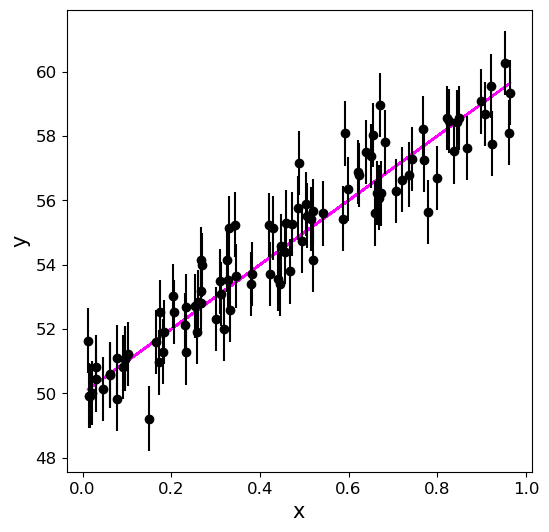

In [4]:
N = 99  # number of points
m = 10.  # slope
b = 50.  # intercept
sigma = 1.  # scatter

rng = np.random.default_rng(seed=6563)  # this seed guarantees everyone will get the same data
x = rng.uniform(low=0, high=1, size = N) # use a uniform distribution to generate random values between 0 and 1
y_noiseless = m*x + b  # equation for a line
y =  y_noiseless + rng.normal(loc = 0, scale = sigma, size = N)  # this adds random noise from a Gaussian centered at 0 with std sigma
dy = np.full((1,N), sigma) # array of error bars for all the data (all sigma) --> np.full fills array of given shape with a fill value

# plotting:
plt.figure(figsize = (6,6))  # create figure
plt.plot(x, y_noiseless, c = 'magenta')  # plotting noiseless data as a line
plt.errorbar(x, y, yerr = dy, fmt = 'o', c = 'k')  # plotting noisy data as points with error bars
plt.xlabel('x', fontsize = 15)  # specify labels & font sizes
plt.ylabel('y', fontsize = 15)
plt.tick_params(axis = 'both', labelsize = 12)

## 2. Write Down the Posterior
Define functions that return the prior, the likelihood, and the posterior given a parameter vector `theta = [m, b]`. For computational accuracy (and convenience), we actually want to do this in log space. Regardless of the shape of your prior, it's good practice to limit the values of $m$ and $b$ to some reasonable range. *[0.75 point]*

**Bayes Theorem**

The posterior is proportional to the likelihood $\mathcal{L}$ times the prior on the parameters $\boldsymbol{\theta} = m, b$:

$$ p(\boldsymbol{\theta} | \mathrm{data}) \propto \mathcal{L}(\mathrm{data} | \boldsymbol{\theta}) \times p(\boldsymbol{\theta}) $$

**Likelihood**

Assuming Gaussian errors, the likelihood for each data point given the model with parameters $\theta$ will be:

$$ \mathcal{L}_i(y_i | \boldsymbol{\theta}, x_i, \sigma_i) = \frac{1}{\sqrt{2\pi \sigma_i^2}} \exp\left[-\frac{(y_i - y_\mathrm{model}(x_i, \boldsymbol{\theta}))^2}{2 \sigma_i^2}\right] $$

Or in log space:

$$ \ln \mathcal{L}_i(y_i | \boldsymbol{\theta}, x_i, \sigma_i) = -\frac{1}{2} \left( \ln{2\pi \sigma_i^2}  + \left[\frac{y_i - y_\mathrm{model}(x_i, \boldsymbol{\theta})}{\sigma_i}\right]^2 \right) $$

Assuming the data are independent, the likelihood for obtaining all of the data points is the product of the individual likelihoods:

$$ \mathcal{L}(\mathbf{y} | \boldsymbol{\theta}, \mathbf{x}, \boldsymbol{\sigma}) = \prod_i \mathcal{L}_i(y_i | \boldsymbol{\theta}, x_i, \sigma_i) $$

Or in log space you can sum the log likelihoods:

$$ \ln \mathcal{L} = \ln \left(\prod_i \mathcal{L}_i \right) = \sum_i \ln \mathcal{L}_i $$

**Prior**

The simplest prior is a uniform prior to restrict the parameters to some range, e.g.:

$$ m = \begin{cases}
1, & 0 < m < 100\\
0, & \mathrm{otherwise}
\end{cases}$$

In [6]:
# define max & min values for m & b
m_min = 0.
m_max = 100.
b_min = 0.
b_max = 100.

# log prior function:
def log_prior(theta):
    """
    Returns log(prior) for a given parameter vector
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]
    
    Returns
    -------
    ln_prior: float, or array of floats
        Natural log of the prior probability function
    """
    # nts: log(prior) means log(p(θ))
    # we need to calculate the prior for m & the prior for b & then multiply them together for the resulting prior!
    
    # first define arrays for m & b by indexing theta
    m_arr, b_arr = theta

    # for each parameter we will have an array of 1's & 0's depending on if the condidion is met. Initialize these arrays & fill with 0's
    shape = np.shape(m_arr)  # note shape of m is same as shape of b
    m_fin_arr = np.full(shape, 0)  # array of 0s with same shape as m
    b_fin_arr = np.full(shape, 0)  # array of 0s with same shape as b

    m_match = (m_min <= m_arr) & (m_arr <= m_max)  # next check whether the values in the m & b arrays fall within the restricted range
    b_match = (b_min <= b_arr) & (b_arr <= b_max)  # note this will return an array of the same shape as m & b filled with booleans
                                                   # (True if meets condition, False if doesn't --> the 'otherwise' case)

    m_fin_arr[m_match] = 1  # this changes the values in our 0 arrays to 1's wherever the index is true in our boolean arrays
    b_fin_arr[b_match] = 1  # in other words, these arrays are 1 where the condition is met (True) & 0 otherwise

    prior = m_fin_arr * b_fin_arr  # our final result is these multiplied together
    ln_prior = np.log(prior)  # take the natural log
     
    return ln_prior  # return result


# log likelihood function:
def log_likelihood(theta, x, y, dy):
    """
    Returns log(likelihood) for a given parameter vector, data, and errors (assuming Gaussian uncertainties)

    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]

    x: array-like 
        Independent variable data points

    y: array-like
        Dependent variable data points

    dy: array-like
        Uncertainties corresponding to y

    Returns
    -------
    lnL: float, or array of floats
        Natural log of the liklihood
    """

    m, b = theta  # define m & b values from theta
    x_vals = x  # x values are given by x entry
    y_vals = y  # y values are gien by y entry
    σ = dy  # sigma values are given by dy entry

    mu = m[...,np.newaxis]*x_vals + b[...,np.newaxis]  # adds dimension & fills with mu values

    ln_quant = np.log(2 * np.pi * σ**2)  # calulcate quantity in ln
    sq_quant = ((y - mu)/σ)**2  # calculate quantity that is squared

    lnL_arr = -0.5 * (ln_quant + sq_quant)  # calculate lnL array
    lnL = np.sum(lnL_arr, axis = -1)  # sum along last dimension (one we just added) for final lnL value(s)
    return lnL  # return results


def log_posterior(theta, x, y, dy):
    """
    Returns log(liklihood) for a given parameter vector, data, and errors (assuming Gaussian uncertainties)

    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]

    x: array-like 
        Independent variable data points

    y: array-like
        Dependent variable data points

    dy: array-like
        Uncertainties corresponding to y

    Returns
    -------
    ln_posterior: float, or array of floats
        Natural log of the posterior
    
    """

    # In log space log(p(θ|data)) α log(L(data|θ) x p(θ)) = log(L(data|θ)) + log(p(θ)), so:
    ln_posterior = log_prior(theta) + log_likelihood(theta, x, y, dy) 

    return ln_posterior  # return result

## 3. Grid Search
### 3a. Evaluate the Posterior on a Grid
Now that you have defined `log_posterior`, produce a grid of $m$ and $b$ values, and evaluate the posterior at each point on the grid. Plot the results using `plt.contour` (contour plot) or `plt.contourf` (filled contour plot). Plot the input values of $m$ and $b$ as a point to see where they sit in the posterior space. *[0.75 point]*

For extra credit, do it with no loops. Hint: read about `np.meshgrid`. You may need to edit your functions above to handle 2D arrays. *[+0.5 point]*

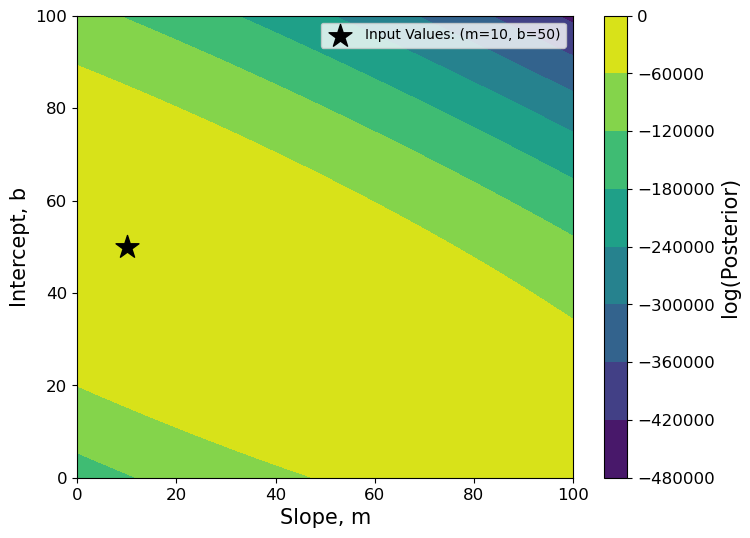

In [8]:
grid_spacing = 1.
nbins = 500
m_range = np.linspace(m_min, m_max, nbins) # m values using linspace
b_range = np.linspace(b_min, b_max, nbins) # b values using linspace

m_grid, b_grid = np.meshgrid(m_range, b_range)  # meshgrid produces grid of m & b values, allowing us to do calculations for at every m & b
theta_range = [m_grid, b_grid]  # define theta!

posterior_grid = log_posterior(theta_range, x, y, dy)  # use log_posterior function to create posterior grid

# plot!
plt.figure(figsize = (8,6))  # create figure
plt.contourf(m_grid, b_grid, posterior_grid)  # use plot.coutourf to plot filled contour plot of results
plt.xlabel('Slope, m', fontsize = 15)  # add axis labels 
plt.ylabel('Intercept, b', fontsize = 15)
cbar = plt.colorbar()  # add colorbar
cbar.set_label('log(Posterior)', fontsize = 15)
cbar.ax.tick_params(labelsize = 12)
plt.tick_params(axis = 'both', labelsize = 12)

# plot the input 'truth'
plt.scatter(10, 50, s = 300, marker= '*', c = 'k', label = 'Input Values: (m=10, b=50)')
plt.legend()

### 3b. Maximize the Posterior
Find the parameters that maximize the posterior distribution. Calculate the fractional error with respect to the parameters we used to generate the data. *[0.75 point]*

In [10]:
# Find the indices where the posterior is maximized --> what m and b is this?
j_max, i_max = np.where(posterior_grid == np.max(posterior_grid)) # np.where returns indices where condition is met, in this case where 
                                                                  # the max value of the posterior grid is

m_infer = m_range[i_max[0]]  # m_infer is m the value at this index. note that since meshgrid fills x & then y, we index m values column wise
b_infer = b_range[j_max[0]]  # & b values row wise
print(f'm = {m_infer:.1f}, b = {b_infer:.1f}')  # print results

# Fractional error of the inferred solution compared to the input 'true' parameters
m_frac_err =  (m_infer - m) / m  # calculate fractional errors by subtracting true value from inferred & dividing by true
b_frac_err =  (b_infer - b) / b   
print(f'Δm/m = {m_frac_err:.3f}, Δb/b = {b_frac_err:.3f}')  # print results

m = 9.8, b = 50.1
Δm/m = -0.018, Δb/b = 0.002


### 3c. Marginalize Over Each Parameter
Since you have a grid of points, it is easy to integrate (sum) along the rows and columns of the grid. Use this method to find the marginalized posterior for each parameter and plot the results. Compare the peaks of these distributions to our input parameters. (Hint: use the `axis` keyword in `np.sum`.) (Another hint: integrate the probability, not the log of the probability.) *[0.75 point]*

**Marginalization**

If we just want to know the posterior for one parameter, we need to marginalize over all the possible values of the other parameter(s).

$$ p(\theta_1 | \mathrm{data}) = \int p(\theta_1, \theta_2 | \mathrm{data}) \, d\theta_2 $$

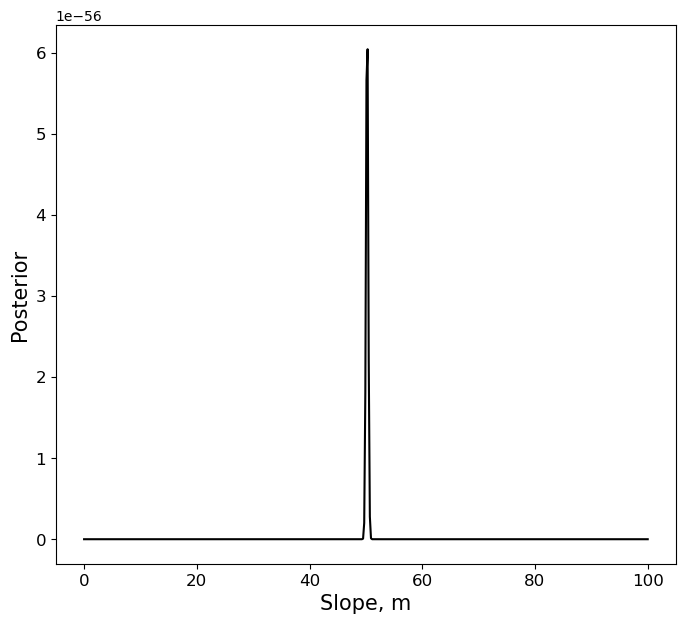

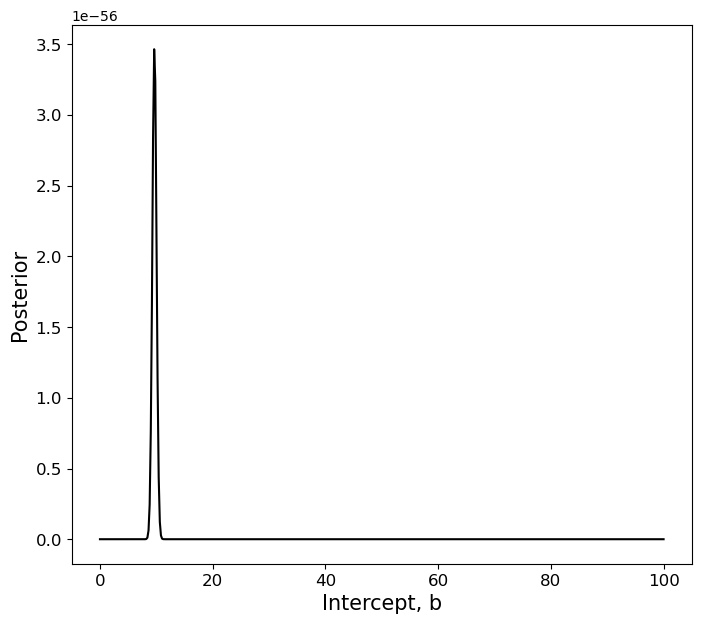

In [12]:
posterior_grid_linear = np.exp(posterior_grid)  # we want to integrate the probability (not the ln of it) so calculate p = e^(ln_p)

# for m:
posterior_marginalized_m = np.sum(posterior_grid_linear, axis = 1) # recall that since meshgrid fillx x,y that m is along the columns & b 
                                                                    # along rows. hence for m we must sum along axis 1 (& for b along axis 0)
# plot!
plt.figure(figsize = (8,7))  # make figure
plt.plot(m_range, posterior_marginalized_m, c = 'k')  # plot m values on x & marginalized posterior values on y
plt.xlabel('Slope, m', fontsize = 15)  # add axis labels
plt.ylabel('Posterior', fontsize = 15)
plt.tick_params(axis = 'both', labelsize = 12)


# for b:
posterior_marginalized_b = np.sum(posterior_grid_linear, axis = 0)  # as mentioned, sum along axis 0 for b

# plot!
plt.figure(figsize = (8,7))  # make figure
plt.plot(b_range, posterior_marginalized_b, c = 'k')  # plot b values on x & marginalized posterior values on y
plt.xlabel('Intercept, b', fontsize = 15)  # add axis labels
plt.ylabel('Posterior', fontsize = 15)
plt.tick_params(axis = 'both', labelsize = 12)

## 4. Monte Carlo
Instead of evaluating the posterior at every point on the grid, it can be more efficient to evaluate it on a random sample of points within the parameter space.

### 4a. Evaluate the Posterior on a Random Sample
Generate 10,000 random points using the `np.random` module and evaluate the posterior at each one. Plot them and color code by the posterior. (Use the `c` parameter of `plt.scatter`). Plot the input values of $m$ and $b$ as a point to see where they sit in the posterior space. Compare this to the plot in Problem 3a. *[0.75 point]*

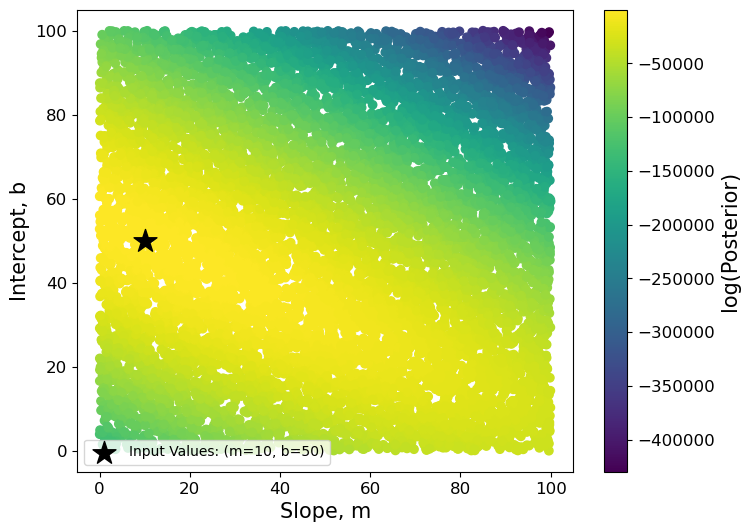

In [14]:
num_points = 10000  # define number of points
m_random = np.random.uniform(size = num_points, low = m_min, high = m_max)  # create random uniform distribution between 0 & 100 for m
b_random = np.random.uniform(size = num_points, low = b_min, high = b_max)  # & a random uniform distribution between 0 & 100 for b
theta_random = [m_random, b_random]  # define theta

posterior_random = log_posterior(theta_random, x, y, dy) # use log_posterior function to calculate posterior for each theta

# plot!
plt.figure(figsize = (8,6))  # create figure
plt.scatter(m_random, b_random, c = posterior_random)  # plot m vals on x axis, b vals on y, with color coding given by log posterior vals
plt.xlabel('Slope, m', fontsize = 15)  # add axis labels
plt.ylabel('Intercept, b', fontsize = 15)
cbar = plt.colorbar()  # add colorbar
cbar.set_label('log(Posterior)', fontsize = 15)
cbar.ax.tick_params(labelsize = 12)
plt.tick_params(axis = 'both', labelsize = 12)

# plot the input 'truth'
plt.scatter(10, 50, s = 300, marker= '*', c = 'k', label = 'Input Values: (m=10, b=50)')
plt.legend()

### 4b. Maximize the Posterior
As before, find the parameters that maximize the posterior distribution. Calculate the fractional error with respect to the parameters we used to generate the data. *[0.75 point]*

In [16]:
# Find the index of the sample where the posterior is maximized --> what m and b is this?
i_max = np.argmax(posterior_random)  # use argmax to find max log posterior value
m_infer_random = m_random[i_max]  # inferred m value is m at that index
b_infer_random = b_random[i_max]  # inferred b value is b at that index
print(f'm = {m_infer_random:.1f}, b = {b_infer_random:.1f}')  # print results

# Fractional error of the inferred solution compared to the input 'true' parameters
m_frac_err_random = (m_infer_random - m) / m  # calculate fractional errors as before
b_frac_err_random = (b_infer_random - b) / b
print(f'Δm/m = {m_frac_err_random:.3f}, Δb/b = {b_frac_err_random:.3f}')  # print results

m = 9.7, b = 50.2
Δm/m = -0.029, Δb/b = 0.004


### 4c. Marginalize Over Each Parameter
Note that it's complicated to calculate the marginalized posteriors using this method. You would have to do some kind of binning or interpolation. Don't worry about that for now. *[0 points]*

## 5. Markov Chain Monte Carlo
This time we will use the `emcee` package that you imported above to sample the posterior probability distribution. Everything you need is contained within the `emcee.EnsembleSampler` class. For now, 100 walkers and 10,000 steps is more than enough, and should run in less than a minute on your laptop. 

In [19]:
n_params = 2  # number of parameters
n_walkers = 100  # number of walkers
n_steps = 10000  # number of steps

### 5a. Pick the Starting Positions
You'll need to give initial guesses for each walker, which you can draw randomly from the prior. *[0.5 point]*

In [21]:
# note, using same rng as before to cross check answers with classmates
m_random =  rng.uniform(low = m_min, high = m_max, size = n_walkers)  # for each walker draw a number between m_min & m_max
b_random =  rng.uniform(low = b_min, high = b_max, size = n_walkers) # do the same for b
initial_guesses =  np.array([m_random, b_random]).T  # array combining initial guesses for both parameters
                                                    # note must transpose from (ndim, nwalkers) --> (nwalkers, ndim) so each row is a 
                                                    # single walkers m & b values 

### 5b. Initialize and Run!
Initialize the `EnsembleSampler` object with 100 walkers and the `log_posterior` function you defined above. Don't forget that `log_posterior` takes additional arguments `x`, `y`, and `dy`. (Hint: check the documentation for `EnsembleSampler` for how to deal with this.) Then run it with the `run_mcmc` method. If this command takes too long, ask for help. *[0.5 point]*

In [23]:
# initialize the sampler
n_dim = np.shape(initial_guesses)[1]  # recall initial_guesses has shape (nwalkers, ndim)

# initialize EnsembleSampler with number of walkers, number of dimensions, and the log_posterior function
sampler = emcee.EnsembleSampler(
                    nwalkers = n_walkers,
                    ndim = n_dim,
                    log_prob_fn = log_posterior,
                    args = [x, y, dy]  # the log posterior function will be called with the sequence (p, *args, **kwargs) where p represents
                                      # the model parameters, *args is the extra positional arguments taken by the function & **kwargs
                                    # is extra keyword arguments taken. in our case, p = theta, and args are x, y, & dy (no kwargs)
                    )


# run!
sampler.run_mcmc(initial_guesses, n_steps)  # must pass our initial guesses & number of steps

/var/folders/gs/vb2qkp7x2snfbtft7nhxpnqc0000gn/T/ipykernel_77612/2285025661.py:41: RuntimeWarning: divide by zero encountered in log
  ln_prior = np.log(prior)  # take the natural log


State([[ 9.91344361 50.06927198]
 [ 9.34522714 50.29687408]
 [ 9.34609378 50.44664321]
 [ 9.64882976 50.26882853]
 [ 9.73052526 50.22203676]
 [ 9.05214686 50.38294313]
 [10.07582676 50.23812182]
 [ 9.23862521 50.52016581]
 [ 9.50327767 50.39065833]
 [ 9.03216754 50.37691435]
 [10.15615294 50.01011912]
 [ 8.88718624 50.57224662]
 [10.18465516 50.01308194]
 [ 8.96376797 50.55731105]
 [ 9.44733702 50.26679066]
 [ 9.10117677 50.47234747]
 [ 9.80924535 50.07981244]
 [ 9.13449383 50.54208006]
 [10.11751037 49.98982772]
 [ 9.88913314 50.12989002]
 [ 9.6736994  50.15838503]
 [ 9.58784517 50.34242572]
 [ 9.89432056 50.07925835]
 [ 9.01524132 50.52596417]
 [ 9.12137003 50.49812097]
 [ 9.92394945 50.12880777]
 [ 9.36334349 50.3038146 ]
 [ 9.92500326 50.1590064 ]
 [ 9.79880498 50.12892277]
 [ 9.89994385 49.97032666]
 [10.52269617 49.63986191]
 [ 9.86793905 50.12453452]
 [ 9.99868382 50.12362681]
 [ 9.20703945 50.35264848]
 [ 9.37490868 50.39056245]
 [ 9.96981327 49.97168234]
 [10.23980525 49.91447

### 5c. Plot the Chains
First make a plot of the walker positions (value of each parameter) at each step. Write a function to do this, since you'll be using it a lot. *[0.5 point]*

(100, 10000, 2)


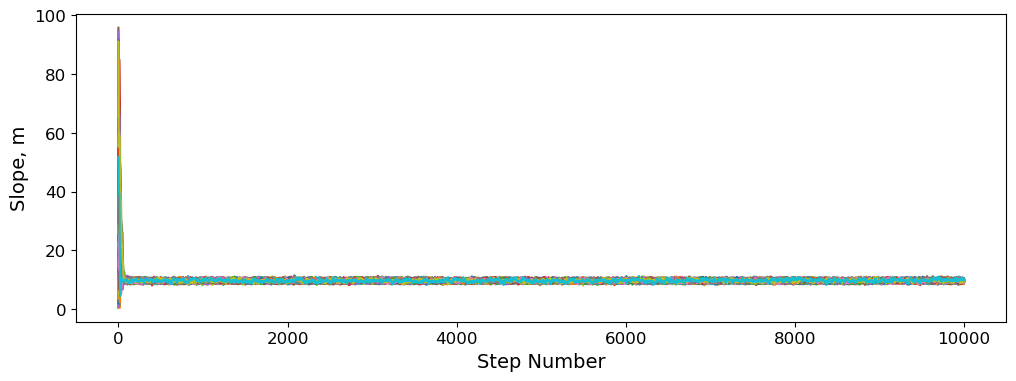

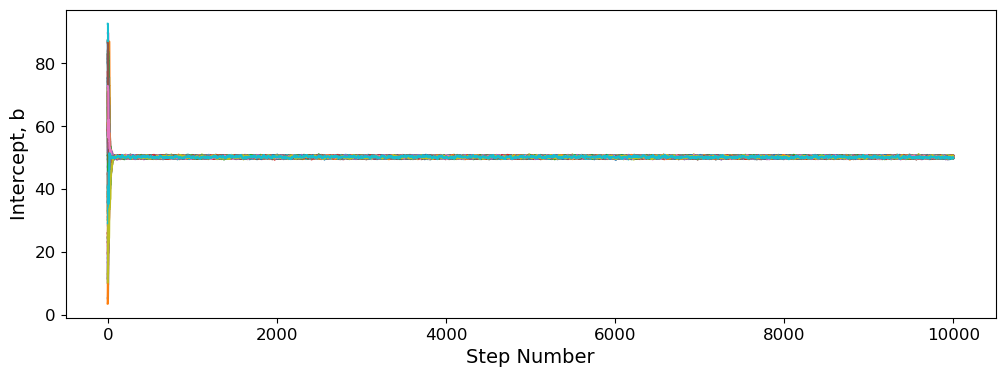

In [25]:
print(sampler.chain.shape)  # check that this has dimensions (n_walkers, n_steps, n_params) --> yes, it does!


def chain_plots(chain, **kwargs):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    
    # for m:
    plt.figure(figsize=(12,4))  # create figure
    plt.plot(chain[:,:,0].T)  # recall dimension of chain is (n_walkers, n_steps, n_params). we grab all walkers & their steps & the 0th
                             # index for m. transpose so that number of steps is on x axis & walker values on y 
    plt.xlabel('Step Number', fontsize = 14)  # add axis labels
    plt.ylabel('Slope, m', fontsize = 14)
    plt.tick_params(axis = 'both', labelsize = 12)
    

    # for b:
    plt.figure(figsize=(12,4))  # create figure
    plt.plot(chain[:,:,1].T)  # same procedure as for m, but grab 1st index for b values instead
    plt.xlabel('Step Number', fontsize = 14)  # add axis labels
    plt.ylabel('Intercept, b', fontsize = 14)
    plt.tick_params(axis = 'both', labelsize = 12)
    
chain_plots(sampler.chain)  # use function!

### 5d. Assess Convergence
Each one of those colored lines is a walker. They started out at your initial guesses. What do you immediately notice? Try making more useful plots by zooming in on the relevant parts. Hint: you can adjust line opacity in matplotlib with the `alpha` parameter. *[0.5 point]*

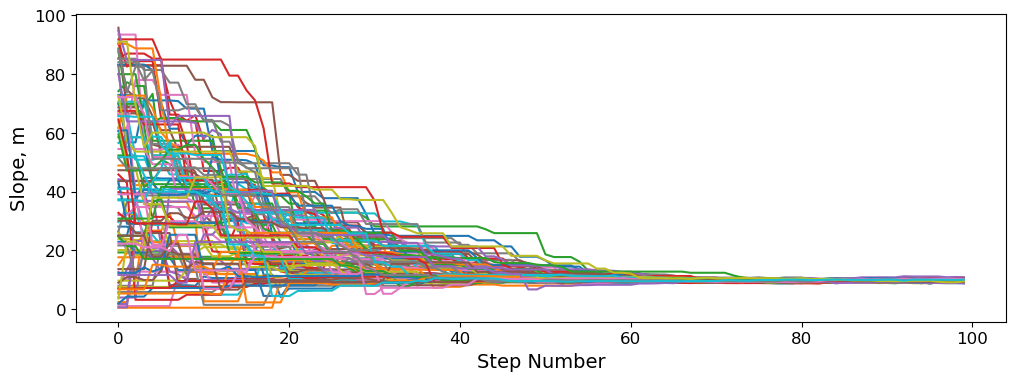

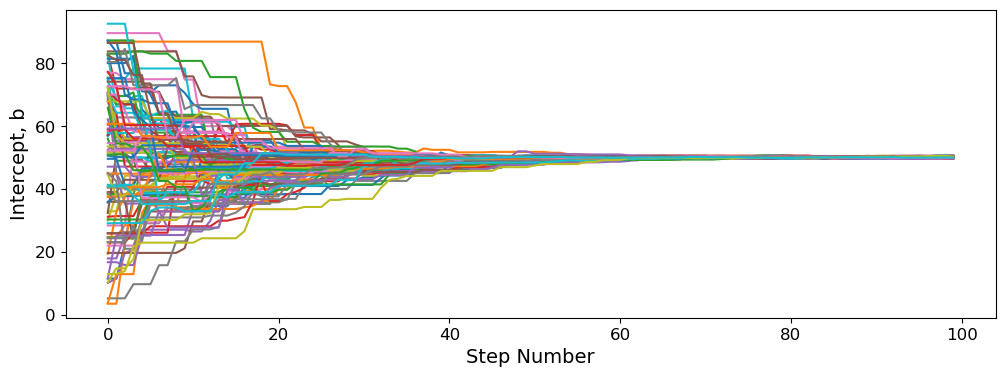

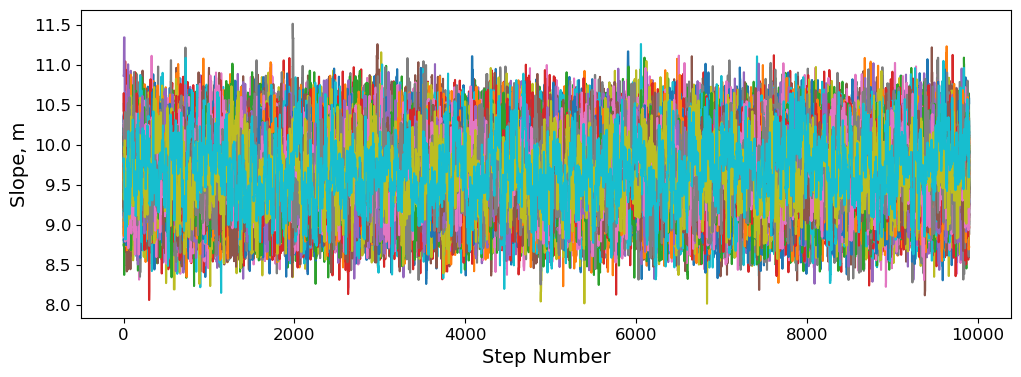

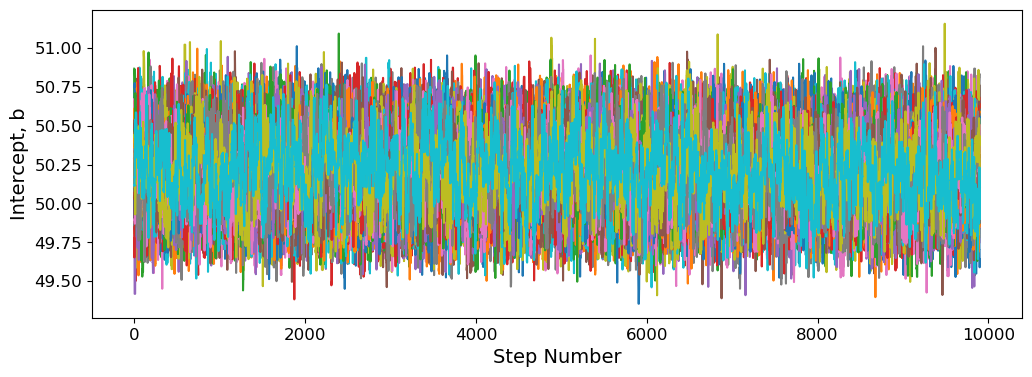

In [27]:
# I immediately notice that wach walker starts out at a different value given by our initial guesses but eventually converge to roughly the 
# same values for m & b (near 10 & 50)

n_burn = 100  # looking at the plots above, values seem to converge by ~100 steps, so take the burn in period to be the first 100 steps
chain_plots(sampler.chain[:,0:n_burn,:])  # plot the burn in (steps from 0 --> n_burn)
chain_plots(sampler.chain[:,n_burn:,:])  # plot the after burn in / convergent period (steps from n_burn --> 10000)

Are your chains converged? How do you know? How many steps did it take for this to happen? This is called the "burn-in" period. *[0.5 point]*

As mentioned in the comments above, the chains are converged! I guessed for them to be converged after 100 steps, but from our plots this seems to happen even earlier! By roughly 80 steps for m & 60 for b!

We know that the chains have convereged because we see the walkers start in their different initial positions and walk to roughly the same values. Since they walk to roughly the same m & b, they have converged to these values. We see this on our plots, with walkers at different initial guesses to start & then roughly the same values after 50-100 steps (looks like going from a range of values to roughly a straight line on our first plot).

**From now on, only use the steps after the burn-in period.**

### 5e. Assess Covariance Between Parameters
Now make a scatter plot of the two parameters, one point for each walker-step. Hint: `sampler.flatchain`. Plot the input values of $m$ and $b$ as a point to see where they sit in the posterior space. *[0.5 point]*

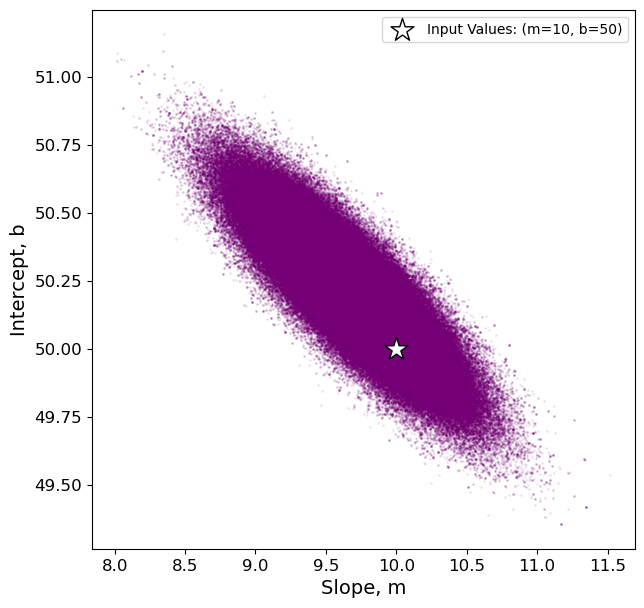

In [32]:
# we want a scatter plot of m & b values after the burn in period. we can use flatchain which flattens chain from
# (n_walkers, n_steps, n_params) --> (n_steps, n_params). Flattening the chain means we cannot remove burn in by just indexing 
# [100:, 0] similar to before. Instead of removing the first 100 steps of all walkers this would just remove the first 100 steps (which would
# be the first step of each of the 100 walkers). To remove the first 100 steps of all the walkers we must now remove the 
# first 100 steps * the number of walkers.

m_steps = sampler.flatchain[n_burn * n_walkers:,0] # m values with burn in removed as described
b_steps = sampler.flatchain[n_burn * n_walkers:,1] # b values with burn in removed as described

# plot! 
plt.figure(figsize=(7,7))  # create figure
plt.scatter(m_steps, b_steps, s = 1, c = '#750075', alpha = 0.08)  # create scatter plot of m & b values after burn in 
plt.xlabel('Slope, m', fontsize = 14)  # add axis labels
plt.ylabel('Intercept, b', fontsize = 14)
plt.tick_params(axis = 'both', labelsize = 12)

# plot 'true' value
plt.scatter(10, 50, s = 300, marker= '*', c = 'white', label = 'Input Values: (m=10, b=50)', lw = 1, edgecolor = 'k')
plt.legend()

How does this plot compare to the distribution you had in Problems 3a and 4a? *[0.5 point]*

This plot has a similar shape to the distributions in Problems 3a & 4a, but now the axes are different (more constrained). This is because the walkers stay primarily in the high-probability regions during MCMC (and especially after removing burn in!). Hence we are not plotting the lower values of the posterior distribution as we did in the other problems, only primarily the high probably regions.

### 5f. Marginalize Over Each Parameter
Now let's marginalize over each parameter. Given that we have walkers that are distributed according to the 2D posterior, think about how to calculate the marginalized posterior for each parameter. *[0.5 point]*

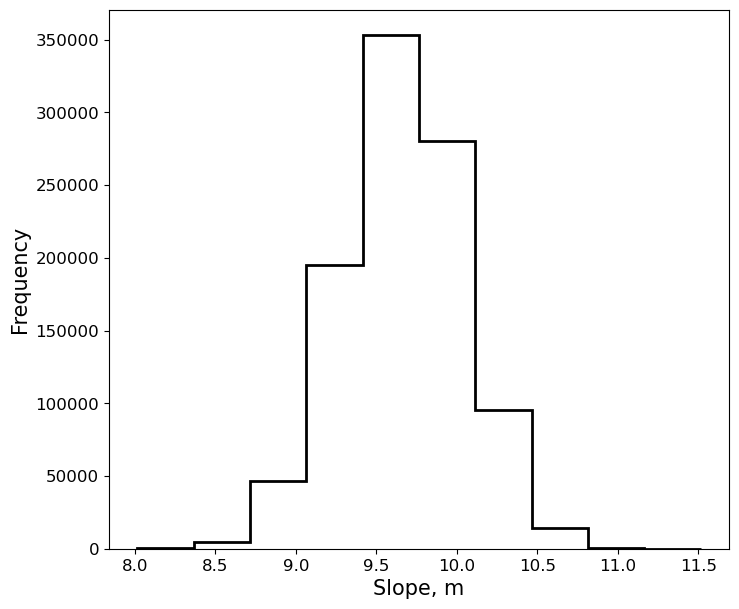

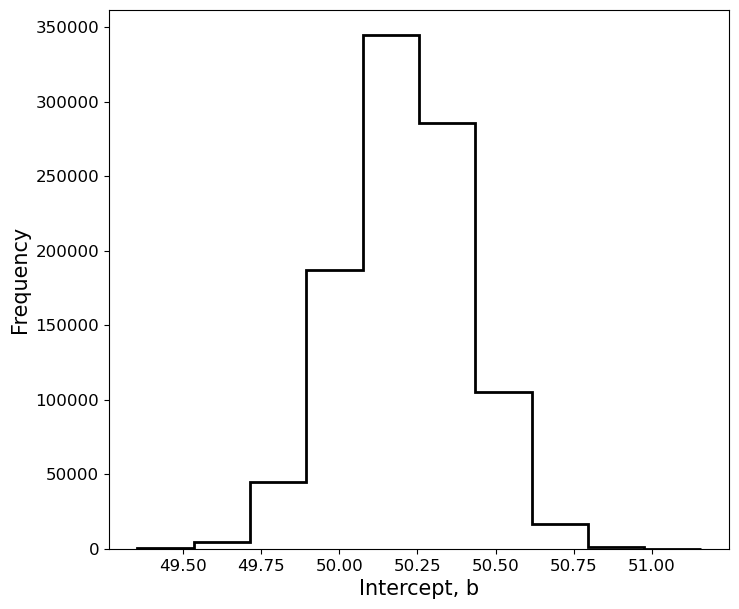

In [36]:
# the marginalized posteriors can essentially be represented with histograms of the walker values. This is because the
# walkers will concentrate/converge in the higher probability density regions, hence higher frequency of walkers at a particular parameter 
# value on a histogram corresponds to the parameter value with the higher probability density

# for m:
plt.figure(figsize = (8,7))  # create figure
plt.hist(m_steps, color = 'k', histtype = 'step', lw = 2)  # plot histogram of m values (customize color, fill, & line width)
plt.xlabel('Slope, m', fontsize = 15)  # add labels
plt.ylabel('Frequency', fontsize = 15)
plt.tick_params(axis = 'both', labelsize = 12)

# for b:
plt.figure(figsize = (8,7))  # create figure
plt.hist(b_steps, color = 'k', histtype = 'step', lw = 2)  # plot histogram of m values (customize color, fill, & line width)
plt.xlabel('Intercept, b', fontsize = 15)  # add labels
plt.ylabel('Frequency', fontsize = 15)
plt.tick_params(axis = 'both', labelsize = 12)

### 5g. Calculate Credible Regions
Calculate the medians and the 68% ($1\sigma$) confidence intervals for each parameter. Compare your answers to the centers and widths of the distributions you just plotted above. *[0.5 point]*

In [38]:
# for m:
m_quants = np.quantile(m_steps, [0.16, 0.5, 0.84])  # calculate value of m_steps at the 0.16 = 0.5 - 34, 0.5, and 0.84 = 0.5 + 0.34 regions
m_med = m_quants[1]  # median is given by the 0.5 quantile value
dm_lo = m_med - m_quants[0]  # dm low is given by the median minus the 0.16 quantile value
dm_hi = m_quants[2] - m_med  # dm high is given by the 0.84 quantile value minus the median 
print(rf'$m = {m_med:.2f}_{{{-dm_lo:+.2f}}}^{{{dm_hi:+.2f}}}$')  # print results (they agree with histogram above!)

# for b:
b_quants = np.quantile(b_steps, [0.16, 0.5, 0.84])  # same process as with m
b_med = b_quants[1]
db_lo = b_med - b_quants[0]
db_hi = b_quants[2] - b_med
print(f'$b = {b_med:.2f}_{{{-db_lo:+.2f}}}^{{{db_hi:+.2f}}}$')  # print results (they agree with histogram above!)

$m = 9.67_{-0.37}^{+0.37}$
$b = 50.21_{-0.19}^{+0.19}$


### 5h. Corner Plot
There's an easy way to make all these plots: `corner.corner`! Produce a corner plot with the true parameters labeled and the best-fit values (with error bars) printed on the plot. Compare your answers to to the parameters we used to generate the data. *[0.5 point]*

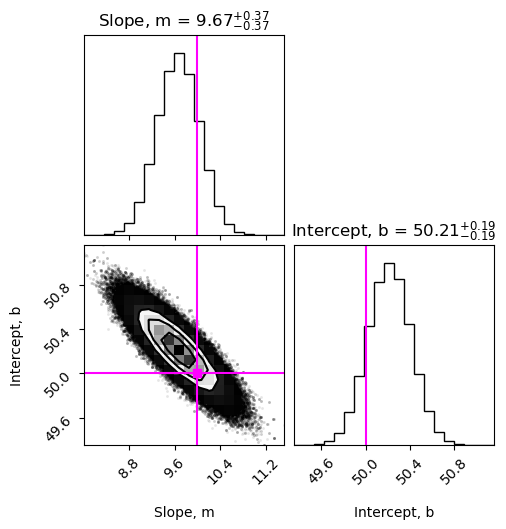

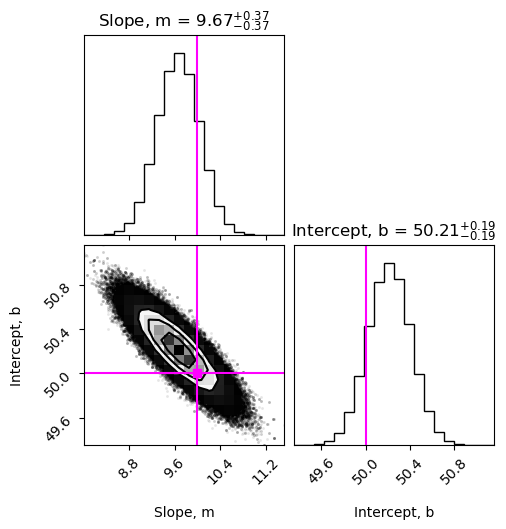

In [71]:
# complete
theta_arr = np.array([m_steps, b_steps]).T  # specify theta array using post burn in values. transpose because corner.corner expects data 
                                            # as (nsteps, ndim)
labels = ['Slope, m', 'Intercept, b']  # specify plot labels
truths = (10, 50)  # specify truth values
# plot corner plot including labels & truth values! show_titles = True displays the median with uncertainty that we calculated earlier
corner.corner(theta_arr, labels = labels, truths = truths, show_titles = True, truth_color = 'magenta')

## Take-Away Message
All three of these methods work, but the point is it's wasteful (and impossible for higher dimensons or large $N$) to be sampling the posterior when the probability density is $e^{-100000}$. MCMC is a much more efficient way to sample the probability distribution because the walkers mostly stay in the highest-probability region. Plus it essentially gives you the marginalized posteriors for free, because the density of walkers matches the probability density.

## 6. Other Things to Try
These are extra credit for ASTR 154. Students in ASTR 254 should do at least 1 point of this for full credit; any more will be extra. You can use functions from above, but please do not overwrite your previous answers or we will not be able to grade them! Add as many cells as you need below.
- Redo the experiment but with a different prior. How much do your results change? Try plotting the priors on top of your marginalized posteriors. *[+0.5 point]*
- Redo the experiment but with a much larger scatter. How well do you do? Now do the priors affect your results? *[+0.5 point]*
- Add another parameter to your model: the intrinsic scatter. See if you can recover the value you used to generate the noisy data. *[+1 point]*
- Try implementing Metropolis-Hastings algorithm yourself and see if you can get the same results as `emcee`. *[+2 points]*

### LAB NOTES

prior: takes in theta array of [slope, intercept], shape = [2, n]. Slope & intercept should each have a shape [n]

returns ln_prior: shape = [n] --> returns one liklihood for each pair of slope & theta

don't worry about normalization


liklihood takes in theta, x, y, dx

x, y, dy are your data, shape [m] 

need to calculate liklihood by expanding slope & to shape = [n,m]. sum on m axis, collapse to [n]

(evaluate liklihood of pair of slope & intercept & sum up)

returns ln_likelihood shape = [n]


y_model = m[...,np.newaxis] adds a new axis to end of m (... is like a wild card for everything before

y_model = m[...,np.newaxis]*x + b[...,np.newaxis]

collapse along last axis for ln_like, collapse along data axis

kinda have to do this way for meshgrid extra credit...


3D grid search.

np.meshgrid takes in linspaces m_lin, b_lin, from limits you set earlier for prior. each [nbins]

do 200 or so bins on each side...

nbins = 500 
m_lin = np.linspace(1, 100, nbins)
b_lin = np.linspace(1, 100, nbins)

np.array(np.meshgrid(m_lin, b_lin))
should be shape of 500 by 500

plt.contourf to plot. takes in countourf([x,y,]z, /, 

linspaces m_lin & b_lin are x & y, ...


dimensions of mcmc chain on slides

each walker is walking in a 2D grid

nwalkeer y axis n steps x axis (need to transpose for that)